### Scale case: does the existing agency-scale model generalize **within a city**?

**Part 1 of the two-part model-refresh case.** `03_agency_comparison` made the *predictor*
case (our BG predictors vs. the governance-stripped baseline). This notebook makes the
*target / scale* case: it shows the existing **agency-trained** crime model captures
crime **between** cities almost perfectly, but generalizes weakly to the **within-city**
block-to-block variation — which is 95% of the variance and the whole point of a
block-group product. That gap motivates a **city-incident, BG-aggregated target** whose
explicit objective is within-city variation.

**What we compare (same construct on both sides):**
- **Prediction** — `total_pt_ct`: the existing model's per-BG predicted *weighted current
  total crime rate* (`ct` = current, not census tract). It is agency-trained but scored
  per BG. Sourced per city from `data/interim/bg_crime/{city}.parquet` (verified below to
  equal the national `block_group_data.sav`).
- **Ground truth** — `wtotal_rate`: our observed **weighted relative-risk rate** from
  `compute_weighted_scores` (each primary crime's local rate ÷ its national `*_pt_u`
  benchmark, equal-weighted, rescaled to per-1K). This is the *same* weighted construct
  as the prediction, so pred and obs are directly comparable — not a raw count/pop rate.

**Scope:** the 5 full-coverage cities whose incident feeds carry all primary crimes
(houston, chicago, atlanta, kansas_city, detroit). Property-only cities are excluded
because their observed weighted-total is not comparable.

In [10]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

_here = Path.cwd().resolve()
_root = next(p for p in [_here, *_here.parents] if (p / "src").is_dir())
sys.path.insert(0, str(_root / "src"))

from crime_blockgroup_mapping.config import INTERIM_DIR, MODEL_SAV
from crime_blockgroup_mapping.scores import compute_weighted_scores

CITIES = ["houston", "chicago", "atlanta", "kansas_city", "detroit"]
POP_FLOOR = 250   # drop a handful of tiny-population BGs whose count/pop rates explode
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### 1. Verify the prediction source

`total_pt_ct` in each `bg_crime` cache is read straight from the local
`block_group_data.sav`, which we pulled from
`gs://geospatial-projects/location_inc/ns4/2025q4/block_group_data.sav`. Two checks:

1. the local `.sav` is byte-identical to the GCS object (md5 matched out-of-band:
   `m5JH+hDtEEGcGrk+uog8dw==`), and
2. the cached per-BG `total_pt_ct` equals the raw `.sav` value for every matched BG.

We assert (2) here so the notebook fails loudly if the cache ever drifts from source.

In [11]:
import pyreadstat

sav, _ = pyreadstat.read_sav(str(MODEL_SAV), usecols=["bg_key", "total_pt_ct"])
sav = sav.rename(columns={"total_pt_ct": "sav_pt_ct"})

for city in ["chicago", "houston"]:
    bg = pd.read_parquet(INTERIM_DIR / "bg_crime" / f"{city}.parquet",
                         columns=["geoid", "total_pt_ct"])
    m = bg.merge(sav, left_on="geoid", right_on="bg_key", how="inner")
    max_diff = (m.total_pt_ct - m.sav_pt_ct).abs().max()
    assert max_diff < 1e-9, f"{city}: bg_crime total_pt_ct drifted from .sav"
    print(f"{city:9s}  n={len(m):5d}  max|bg_crime - .sav| = {max_diff:.1e}  -> identical")

print("\nCanonical prediction source = local bg_crime parquet (equals GCS .sav).")

chicago    n= 2256  max|bg_crime - .sav| = 0.0e+00  -> identical
houston    n= 2108  max|bg_crime - .sav| = 0.0e+00  -> identical

Canonical prediction source = local bg_crime parquet (equals GCS .sav).


#### 2. Assemble the per-BG comparison panel

For each city: load the cached `bg_crime`, add the weighted observed rate
(`compute_weighted_scores` → `wtotal_rate`), keep **inside-city** BGs with
`population ≥ 250`, and stack into one panel of `(city, population, pred, obs)`.

In [12]:
def load_panel():
    frames = []
    for city in CITIES:
        d = pd.read_parquet(INTERIM_DIR / "bg_crime" / f"{city}.parquet")
        d = compute_weighted_scores(d)                       # adds wtotal_rate
        d = d[(d.within_city == 1) & (d.population >= POP_FLOOR)]
        d = d.dropna(subset=["total_pt_ct", "wtotal_rate"]).copy()
        d["city"] = city
        frames.append(d[["city", "population", "total_pt_ct", "wtotal_rate"]])
    p = pd.concat(frames, ignore_index=True)
    p = p.rename(columns={"total_pt_ct": "pred", "wtotal_rate": "obs"})
    p["lpred"] = np.log1p(p.pred)
    p["lobs"] = np.log1p(p.obs)
    return p

panel = load_panel()
print("panel BGs:", len(panel))
panel.city.value_counts().reindex(CITIES).to_frame("n_bg")

Weighted scores computed: wtotal_rel median = 1.11, wprop_rel median=1.13
Weighted scores computed: wtotal_rel median = 1.26, wprop_rel median=1.27
Weighted scores computed: wtotal_rel median = 1.08, wprop_rel median=1.15
Weighted scores computed: wtotal_rel median = 1.13, wprop_rel median=1.31
Weighted scores computed: wtotal_rel median = 3.02, wprop_rel median=2.84
panel BGs: 5254


,n_bg
city,
houston,1623
chicago,2154
atlanta,421
kansas_city,464
detroit,592


#### 3. Between-city: the model levels whole cities almost perfectly

Collapse to city means. Because pred and obs are the *same* weighted per-1K construct, we
can compare **magnitude**, not just rank. The city means fall on the 45° line.

       city  pred   obs    n
    houston 62.74 50.53 1623
    chicago 54.58 50.33 2154
    atlanta 53.03 50.13  421
kansas_city 88.50 76.01  464
    detroit 86.19 82.59  592

between-city Pearson = 0.960   Spearman = 0.900


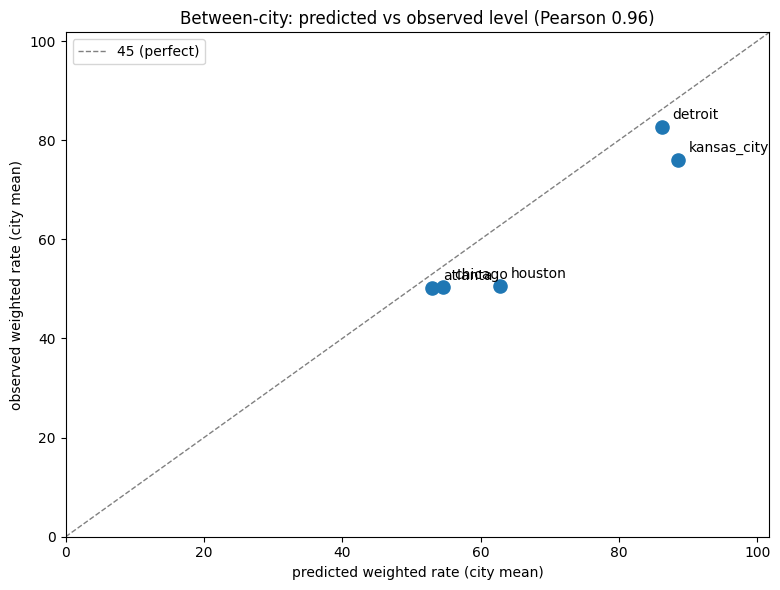

In [24]:
cm = (panel.groupby("city")
      .agg(pred=("pred", "mean"), obs=("obs", "mean"), n=("obs", "size"))
      .reindex(CITIES).reset_index())
between_r = pearsonr(cm.pred, cm.obs)[0]
between_rho = spearmanr(cm.pred, cm.obs)[0]
print(cm.to_string(index=False))
print(f"\nbetween-city Pearson = {between_r:.3f}   Spearman = {between_rho:.3f}")

fig, ax = plt.subplots(figsize=(8,6))
lim = [0, cm[["pred", "obs"]].values.max() * 1.15]
ax.plot(lim, lim, "--", color="grey", lw=1, label="45 (perfect)")
ax.scatter(cm.pred, cm.obs, s=90, zorder=3)
for _, r in cm.iterrows():
    ax.annotate(r.city, (r.pred, r.obs), xycoords ="data", xytext=(8,6), textcoords="offset points")
ax.set(xlim=lim, ylim=lim, xlabel="predicted weighted rate (city mean)",
       ylabel="observed weighted rate (city mean)",
       title=f"Between-city: predicted vs observed level (Pearson {between_r:.2f})")
ax.legend(); plt.tight_layout(); plt.show()

#### 4. But ~95% of the variance is *within* cities — where the fit weakens

Decompose the observed (log) weighted-rate variance into a between-city component (city
means) and a within-city component (block-to-block, city-demeaned). Then measure how well
the prediction tracks the **within-city** (city-demeaned) signal.

**Key Message:**
Total variance is the spread of every block group around the grand mean (the overall average across all 5 cities). Of that total: only 4.8% comes from cities differing from each other (ss_between ), and 95.2% comes from blocks differing from their own city's mean (ss_within). Equivalently, a model that predicted "every block = its city average" would score just R² ≈ 0.05. This is a property of the crime data — city-level averages are nearly interchangeable, while the action is block-to-block inside each city — so a block-group product must resolve the within-city 95%, which justifies the need for a block-group level model.

ss_tot     =   6584.2
ss_between =    318.0  -> between_share = 4.8%
ss_within  =   6266.2  -> within_share  = 95.2%
ss_between + ss_within == ss_tot ? True


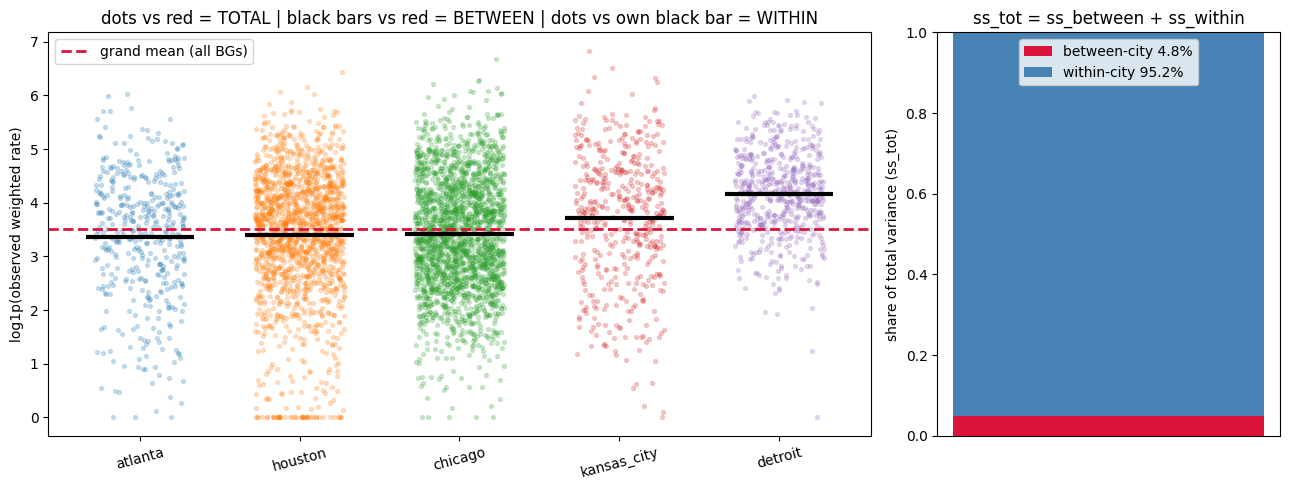

In [ ]:
# panel.lobs is the log1p(observed weighted rate) value
# lobs.mean() is the mean over all block groups of the 5 cities
# ss_tot gives spread of every bg around overall average
grand      = panel.lobs.mean()
ss_tot     = ((panel.lobs - grand) ** 2).sum()
ss_between = panel.groupby("city").apply(lambda g: len(g) * (g.lobs.mean() - grand) ** 2).sum()
ss_within  = ((panel.lobs - panel.groupby("city").lobs.transform("mean")) ** 2).sum()   # only to check the identity

print(f"ss_tot     = {ss_tot:8.1f}")
print(f"ss_between = {ss_between:8.1f}  -> between_share = {ss_between/ss_tot:.1%}")
print(f"ss_within  = {ss_within:8.1f}  -> within_share  = {ss_within/ss_tot:.1%}")
print(f"ss_between + ss_within == ss_tot ? {np.isclose(ss_between + ss_within, ss_tot)}")

order = panel.groupby("city").lobs.mean().sort_values().index.tolist()
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [2.4, 1]})
rng = np.random.default_rng(0)
for i, c in enumerate(order):
    g = panel[panel.city == c]
    axL.scatter(i + rng.uniform(-.28, .28, len(g)), g.lobs, s=8, alpha=.22)
    axL.hlines(g.lobs.mean(), i - .34, i + .34, color="black", lw=3, zorder=5)   # city mean
axL.axhline(grand, color="crimson", ls="--", lw=2, label="grand mean (all BGs)")
axL.set_xticks(range(len(order))); axL.set_xticklabels(order, rotation=15)
axL.set_ylabel("log1p(observed weighted rate)")
axL.set_title("dots vs red = TOTAL | black bars vs red = BETWEEN | dots vs own black bar = WITHIN")
axL.legend(loc="upper left")
axR.bar(0, ss_between/ss_tot, .6, color="crimson",   label=f"between-city {ss_between/ss_tot:.1%}")
axR.bar(0, ss_within/ss_tot,  .6, color="steelblue", bottom=ss_between/ss_tot, label=f"within-city {ss_within/ss_tot:.1%}")
axR.set_xticks([]); axR.set_ylim(0, 1); axR.set_ylabel("share of total variance (ss_tot)")
axR.set_title("ss_tot = ss_between + ss_within"); axR.legend(loc="upper center")
plt.tight_layout(); plt.show()

In [34]:
# Correlations to fit 
# if r=x ⇒ the model explains ~x^2 % of within-city variation, leaving ~(1-x^2)% unexplained.
panel["lpred_dm"] = panel.lpred - panel.groupby("city").lpred.transform("mean")
panel["lobs_dm"] = panel.lobs - panel.groupby("city").lobs.transform("mean")
order    = panel.groupby("city").lobs.mean().sort_values().index.tolist()
# within one city, demeaning only subtracts a constant, so this equals the within-city correlation
per_city = panel.groupby("city").apply(lambda g: pearsonr(g.lpred, g.lobs)[0]).reindex(order)
pooled_r = pearsonr(panel.lpred_dm, panel.lobs_dm)[0]

print(f"Pooled coorelation: {pooled_r:.2f}")
print("="*25)
print(f"Per-city correlation: {per_city}")
print("="*25)
for c, g in panel.groupby("city"):
    r = pearsonr(g.lpred, g.lobs)[0]
    print(f"{c:12s} r={r:.2f}  R2={r**2:.2f}")

Pooled coorelation: 0.57
Per-city correlation: city
atlanta       0.60
houston       0.50
chicago       0.63
kansas_city   0.68
detroit       0.35
dtype: float64
atlanta      r=0.60  R2=0.36
chicago      r=0.63  R2=0.39
detroit      r=0.35  R2=0.12
houston      r=0.50  R2=0.25
kansas_city  r=0.68  R2=0.46


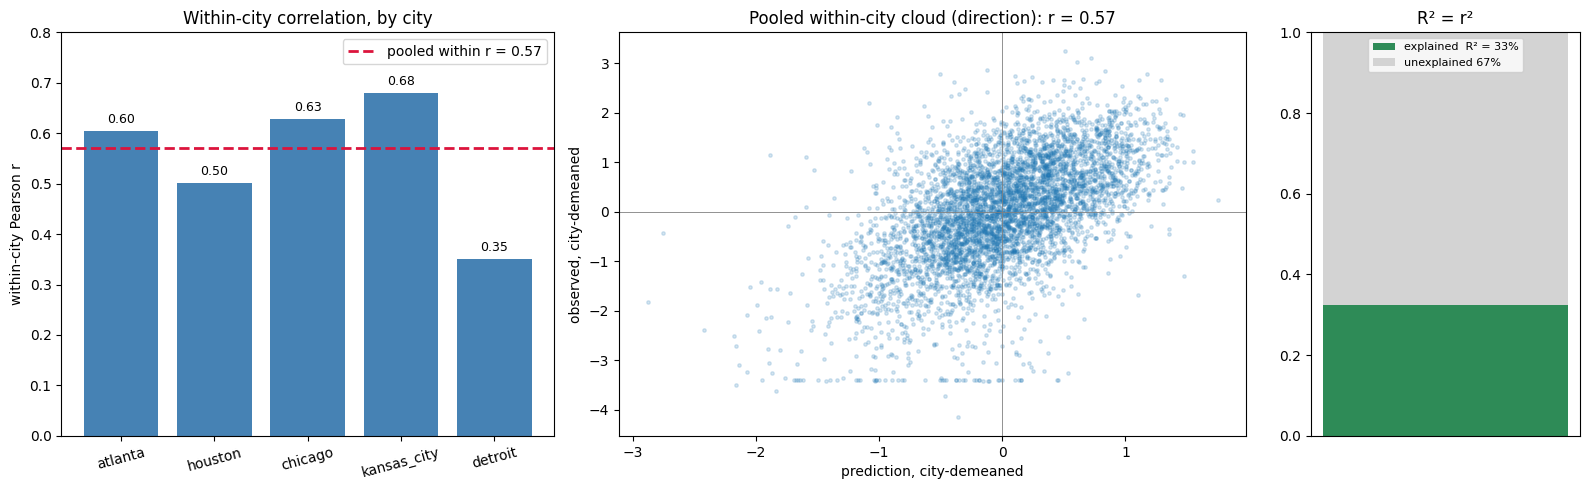

In [35]:
# Visualizing correlations and fit

fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(16, 5), gridspec_kw={"width_ratios": [1.1, 1.4, 0.6]})
a1.bar(range(len(per_city)), per_city.values, color="steelblue")
a1.axhline(pooled_r, color="crimson", ls="--", lw=2, label=f"pooled within r = {pooled_r:.2f}")
for i, v in enumerate(per_city.values):
    a1.text(i, v + .01, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
a1.set_xticks(range(len(per_city))); a1.set_xticklabels(per_city.index, rotation=15)
a1.set_ylim(0, .8); a1.set_ylabel("within-city Pearson r"); a1.set_title("Within-city correlation, by city"); a1.legend()

a2.scatter(panel.lpred_dm, panel.lobs_dm, s=6, alpha=.18)
a2.axhline(0, color="grey", lw=.6); a2.axvline(0, color="grey", lw=.6)
a2.set_xlabel("prediction, city-demeaned"); a2.set_ylabel("observed, city-demeaned")
a2.set_title(f"Pooled within-city cloud (direction): r = {pooled_r:.2f}")

a3.bar(0, pooled_r**2,     .6, color="seagreen", label=f"explained  R² = {pooled_r**2:.0%}")
a3.bar(0, 1 - pooled_r**2, .6, color="lightgrey", bottom=pooled_r**2, label=f"unexplained {1 - pooled_r**2:.0%}")
a3.set_xticks([]); a3.set_ylim(0, 1); a3.set_title("R² = r²"); a3.legend(loc="upper center", fontsize=8)
plt.tight_layout(); plt.show()

**Plotting Quintiles to Understand Under and Over Prediction**
- Existing model is directionally sound
- However, it follows the classic regression to the mean. While that is not bad for bgs where we over-predict, it isn't ideal for high crime bgs where we under-predict 

In [38]:
def obs_quintile_table(g):
    g = g.assign(obs_quintile=pd.qcut(g.lobs_dm, 5,
                 labels=["Q1 lowest", "Q2", "Q3 mid", "Q4", "Q5 highest"]))
    return (g.groupby("obs_quintile", observed=True)
             .agg(actual__obs_dm=("lobs_dm", "mean"),
                  model_says__pred_dm=("lpred_dm", "mean"),
                  n=("lobs_dm", "size"))
             .round(2))

print("POOLED (all 5 cities):")
obs_quintile_table(panel)

POOLED (all 5 cities):


,actual__obs_dm,model_says__pred_dm,n
obs_quintile,,,
Q1 lowest,-1.60,-0.51,1051
Q2,-0.51,-0.17,1051
Q3 mid,0.07,0.03,1050
Q4,0.62,0.22,1051
Q5 highest,1.43,0.42,1051


**Plotting Kansas City and Detroit**
- Kansas City — the red binned line climbs steadily left-to-right: low blocks predicted low, 
high blocks predicted high. Direction is reliable; it's still compressed (stays
inside the 45° line, ~3×) but genuinely usable as a sorter.
- Detroit — the red line is nearly flat, and prediction barely spans any range. 
Critically the high end collapses: the top three observed quintiles all get ~+0.1 — the most
dangerous blocks get essentially the same score as average ones, so the model can't flag them at all. 
Both ends regress almost fully to the city mean.

In [39]:
best_worst = ["kansas_city", "detroit"]   # highest and lowest within-city r
compare = pd.concat(
    {c: obs_quintile_table(panel[panel.city == c]) for c in best_worst},
    axis=1)
compare

kansas_city                                detroit  \
             actual__obs_dm model_says__pred_dm   n actual__obs_dm   
obs_quintile                                                         
Q1 lowest             -1.84               -0.79  93          -1.08   
Q2                    -0.58               -0.14  93          -0.35   
Q3 mid                 0.14                0.03  92           0.02   
Q4                     0.72                0.36  93           0.38   
Q5 highest             1.57                0.53  93           1.04   

                                       
             model_says__pred_dm    n  
obs_quintile                           
Q1 lowest                  -0.32  119  
Q2                         -0.02  118  
Q3 mid                      0.11  118  
Q4                          0.11  118  
Q5 highest                  0.13  119

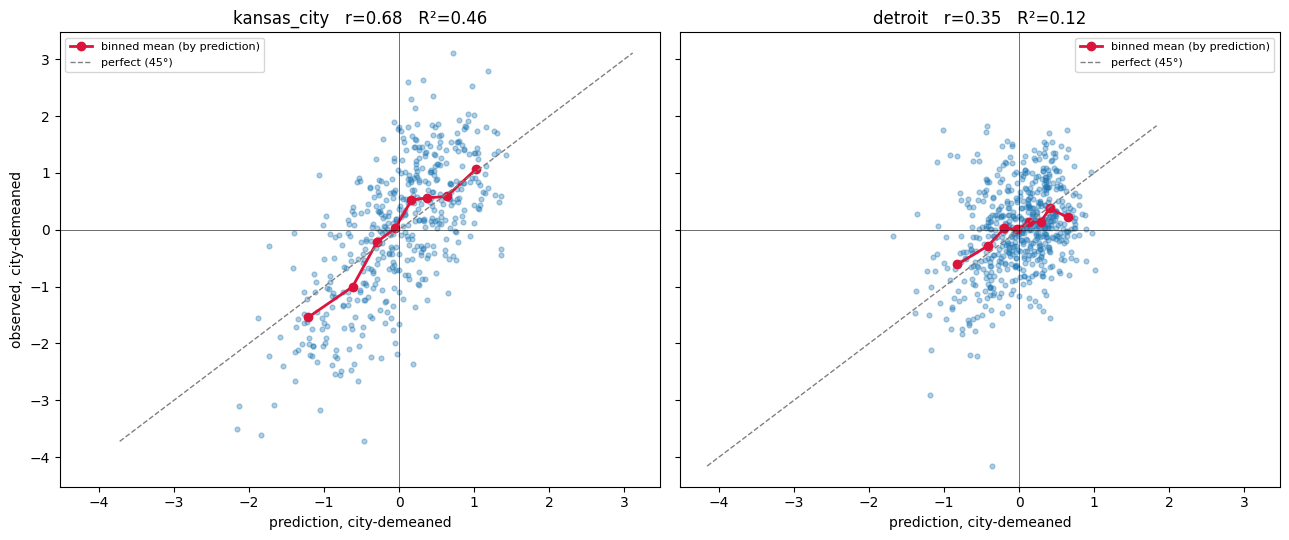

In [36]:
# Plots for the best and worst cities
best_worst = ["kansas_city", "detroit"]   # highest and lowest within-city r

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True, sharey=True)
for ax, c in zip(axes, best_worst):
    g = panel[panel.city == c]
    r = pearsonr(g.lpred, g.lobs)[0]
    ax.scatter(g.lpred_dm, g.lobs_dm, s=12, alpha=.35)
    g2 = g.assign(q=pd.qcut(g.lpred_dm.rank(method="first"), 8, labels=False))
    bm = g2.groupby("q").agg(x=("lpred_dm", "mean"), y=("lobs_dm", "mean"))
    ax.plot(bm.x, bm.y, "o-", color="crimson", lw=2, label="binned mean (by prediction)")
    lim = [min(g.lpred_dm.min(), g.lobs_dm.min()), max(g.lpred_dm.max(), g.lobs_dm.max())]
    ax.plot(lim, lim, "--", color="grey", lw=1, label="perfect (45°)")
    ax.axhline(0, color="k", lw=.4); ax.axvline(0, color="k", lw=.4)
    ax.set_title(f"{c}   r={r:.2f}   R²={r**2:.2f}")
    ax.set_xlabel("prediction, city-demeaned"); ax.legend(fontsize=8)
axes[0].set_ylabel("observed, city-demeaned")
plt.tight_layout(); plt.show()

In [ ]:
# Business-cost diagnostic: of each city's genuinely dangerous blocks (observed
# top decile), where does the model rank them? Under-flagging risk is the costly error.
# obs_pct -> top 10% block groups by observed wtotal_rate
# pred_pct -> top x% block groups by predicted wtotal_rate
# recall -> of the ones in actuals, how many are in predicted. 
# Detroit is the case we should keep front and center for a different model 
panel["obs_pct"]  = panel.groupby("city").obs.rank(pct=True)
panel["pred_pct"] = panel.groupby("city").pred.rank(pct=True)
D = panel[panel.obs_pct >= 0.90].copy()     # truly dangerous = observed within-city top decile

def summarize(df):
    return pd.Series({
        "n_danger": len(df),
        "recall@top10%": (df.pred_pct >= 0.90).mean(),
        "recall@top30%": (df.pred_pct >= 0.70).mean(),
        "called_safe(bottom half)": (df.pred_pct < 0.50).mean()})

tab = D.groupby("city").apply(summarize)
tab.loc["POOLED (micro-avg)"] = summarize(D)
tab["n_danger"] = tab["n_danger"].astype(int)
for c in ["recall@top10%", "recall@top30%", "called_safe(bottom half)"]:
    tab[c] = (tab[c] * 100).round(0).astype(int).astype(str) + "%"
tab.reindex(["houston","chicago","atlanta","kansas_city","detroit","POOLED (micro-avg)"])

,n_danger,recall@top10%,recall@top30%,called_safe(bottom half)
city,,,,
houston,163,26%,58%,20%
chicago,216,38%,76%,9%
atlanta,43,21%,60%,14%
kansas_city,47,26%,64%,11%
detroit,60,10%,45%,37%
POOLED (micro-avg),529,29%,65%,16%


#### 5. The within-city defect is **magnitude compression** (+ inconsistent rank)

Per city we report:
- **Spearman** / **log-Pearson** — does the prediction order blocks correctly within the city?
- **P90/P10 spread** for predicted vs observed — the *dynamic range*. The model squeezes
  blocks into a narrow band while real crime fans out much wider.
- **compression** = obs spread ÷ pred spread — how many times wider reality is than the
  model predicts.
- **decile lift** — observed weighted rate in the top vs bottom predicted decile
  (population-weighted); how much real crime separation the ranking actually buys.

In [ ]:
def p90p10(x):
    x = x[x > 0]
    return np.percentile(x, 90) / np.percentile(x, 10)

def wmean(g, col):
    return np.average(g[col], weights=g.population)

rows = []
for city, g in panel.groupby("city"):
    g = g.copy()
    g["dec"] = pd.qcut(g.pred.rank(method="first"), 10, labels=False)
    lift = wmean(g[g.dec == 9], "obs") / wmean(g[g.dec == 0], "obs") # for the top 10% and bottom 10% predicted by the model, what's the ratio of observed crime rate. Recall uses observed as reference, this uses predicted
    pr_pred, pr_obs = p90p10(g.pred), p90p10(g.obs)
    rows.append({
        "city": city, 
        "n": len(g),
        "spearman": spearmanr(g.pred, g.obs)[0],
        "log_pearson": pearsonr(g.lpred, g.lobs)[0],
        "pred_P90/10": pr_pred, 
        "obs_P90/10": pr_obs,
        "compression_x": pr_obs / pr_pred, 
        "decile_lift_x": lift,
    })
diag = pd.DataFrame(rows).set_index("city").reindex(CITIES)
diag.round(2)

,n,spearman,log_pearson,pred_P90/10,obs_P90/10,compression_x,decile_lift_x
city,,,,,,,
houston,1623,0.47,0.50,4.03,15.39,3.82,6.12
chicago,2154,0.63,0.63,4.80,16.48,3.43,6.10
atlanta,421,0.56,0.60,6.12,26.85,4.39,7.04
kansas_city,464,0.66,0.68,6.34,27.53,4.34,13.23
detroit,592,0.33,0.35,3.24,7.19,2.22,1.80


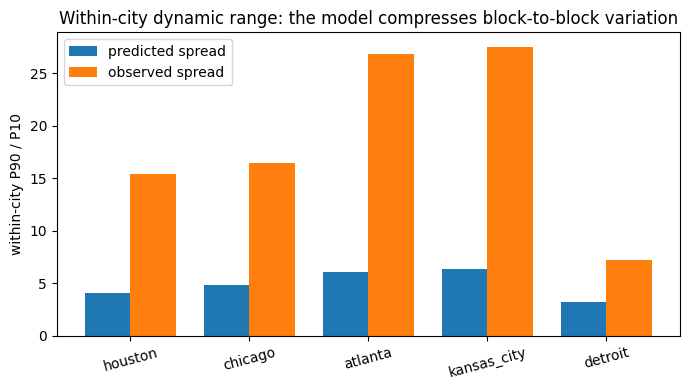

In [8]:
# Compression bar chart: predicted vs observed within-city dynamic range (P90/P10).
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(diag)); w = 0.38
ax.bar(x - w/2, diag["pred_P90/10"], w, label="predicted spread")
ax.bar(x + w/2, diag["obs_P90/10"], w, label="observed spread")
ax.set_xticks(x); ax.set_xticklabels(diag.index, rotation=15)
ax.set_ylabel("within-city P90 / P10"); ax.legend()
ax.set_title("Within-city dynamic range: the model compresses block-to-block variation")
plt.tight_layout(); plt.show()

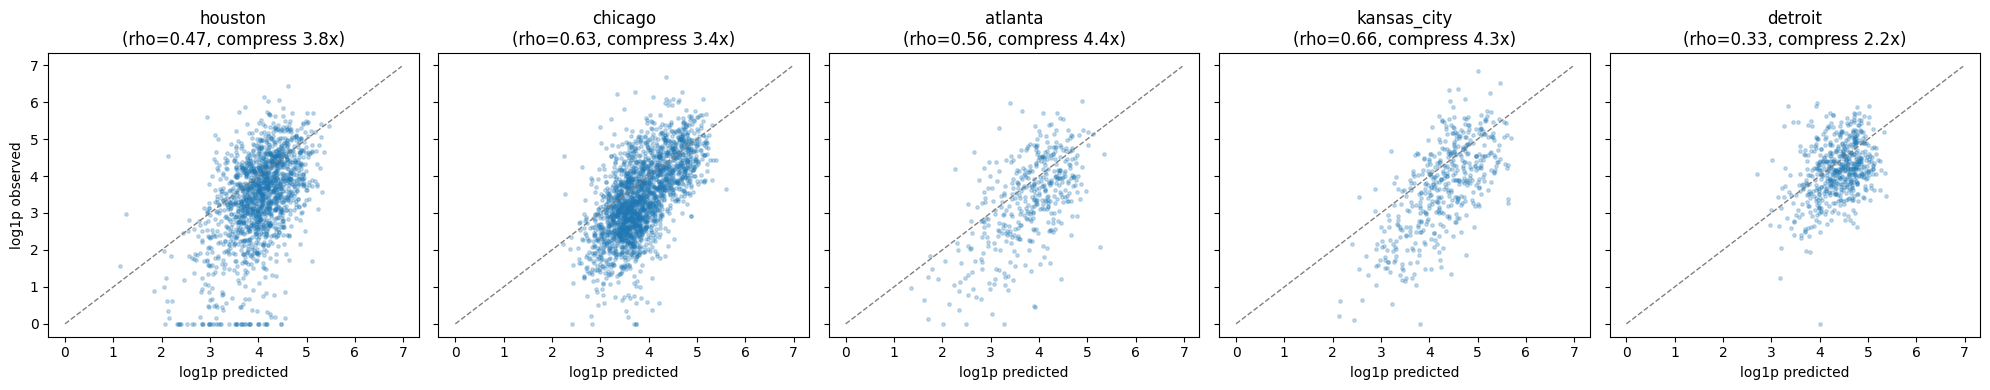

In [9]:
# Small-multiple scatter: within-city predicted vs observed (log-log), 45 line.
# Points smear vertically -> observed fans out while prediction barely moves.
fig, axes = plt.subplots(1, len(CITIES), figsize=(4 * len(CITIES), 4), sharex=True, sharey=True)
for ax, city in zip(axes, CITIES):
    g = panel[panel.city == city]
    ax.scatter(g.lpred, g.lobs, s=6, alpha=0.25)
    lim = [0, max(panel.lpred.max(), panel.lobs.max()) * 1.02]
    ax.plot(lim, lim, "--", color="grey", lw=1)
    ax.set(title=f"{city}\n(rho={diag.loc[city,'spearman']:.2f}, "
                 f"compress {diag.loc[city,'compression_x']:.1f}x)",
           xlabel="log1p predicted")
axes[0].set_ylabel("log1p observed")
plt.tight_layout(); plt.show()

#### 6. Takeaway — why we move to a city-incident, BG-aggregated target

- **Between cities the existing model is excellent.** City-mean predicted and observed
  weighted rates line up almost 1:1 (Pearson ~0.96). The agency-trained model does exactly
  what it was built to do: separate high-crime cities from low-crime ones.
- **But ~95% of the weighted-rate variance is *within* cities**, and that is the variance a
  block-group product must resolve. There the same model:
  - retains only **moderate, city-inconsistent rank** (Spearman ~0.33 in Detroit up to
    ~0.66 in Kansas City), and
  - **severely compresses magnitude** — it predicts a ~3–6x block-to-block spread where the
    observed spread is ~7–28x (2–4x too narrow), so blocks are pulled toward a city-typical
    value instead of separated. In Detroit the ranking barely separates blocks at all
    (decile lift ~1.8x vs 6–13x elsewhere).
- **Honest caveat:** the ranking is not useless — top-vs-bottom predicted-decile lift is
  6–13x in four of five cities — but the magnitude compression and the Detroit-style
  failures show it is not built for within-city discrimination.

**Conclusion.** The agency-scale target is the wrong scale for a within-city product. This
is the target/scale half of the rebuild case (predictors: `03`; target/scale: here) and
motivates training on a **city-incident, BG-aggregated weighted rate** whose explicit
objective is the within-city variation the current model leaves on the table.